# Tectonic Discrimination using Supervised Machine Learning

## Objective

This notebook develops a robust machine learning workflow for discriminating between Orogenic and Anorogenic matrix glass compositions using trace element geochemistry.

The workflow consists of:

1. Data import and quality control
2. Robust feature screening using median and MAD statistics
3. Feature selection
4. Supervised classification
5. Model interpretation
6. External validation
7. Prediction uncertainty analysis

## 1. Environment Setup

Import required libraries, define project directories and initialise the analysis environment.

In [1]:
# =============================================================================
# Environment setup
# =============================================================================

import os
os.environ["OMP_NUM_THREADS"] = "1"

import warnings
warnings.filterwarnings("ignore")

import math
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

ROOT_DIR = Path.cwd().parent

DATA_DIR = ROOT_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

EXPORT_DIR = ROOT_DIR / "exports"
FIGURE_DIR = ROOT_DIR / "figures"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
EXPORT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 99

print("Environment initialised.")
print(f"Root directory   : {ROOT_DIR}")
print(f"Raw data         : {RAW_DIR}")
print(f"Processed data   : {PROCESSED_DIR}")
print(f"Export directory : {EXPORT_DIR}")
print(f"Figure directory : {FIGURE_DIR}")

Environment initialised.
Root directory   : C:\Users\d67199rs\OneDrive - The University of Manchester\Desktop\Lamproite
Raw data         : C:\Users\d67199rs\OneDrive - The University of Manchester\Desktop\Lamproite\data\raw
Processed data   : C:\Users\d67199rs\OneDrive - The University of Manchester\Desktop\Lamproite\data\processed
Export directory : C:\Users\d67199rs\OneDrive - The University of Manchester\Desktop\Lamproite\exports
Figure directory : C:\Users\d67199rs\OneDrive - The University of Manchester\Desktop\Lamproite\figures


## 2. Import Scientific Libraries

Load all statistical, machine learning and visualisation packages required for the workflow.

In [2]:
# =============================================================================
# Scientific libraries
# =============================================================================

from scipy.stats import mannwhitneyu

from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.decomposition import PCA

from sklearn.model_selection import (
    GroupKFold,
    GridSearchCV,
    cross_validate,
    cross_val_predict
)

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from sklearn.neighbors import KNeighborsClassifier

from sklearn.ensemble import ( RandomForestClassifier, ExtraTreesClassifier )

from sklearn.inspection import permutation_importance

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc
)

## 3. Import Dataset

Load the complete geochemical dataset and calculate elemental concentrations from oxide measurements where required.

In [3]:
# =============================================================================
# Import dataset
# =============================================================================

df = pd.read_csv(RAW_DIR / "Data_Input.csv", encoding="utf-8")

df["Ti"] = df["TiO2"] * 0.5994 * 1e4
df["K"] = df["K2O"] * 0.8301 * 1e4
df["P"] = df["P2O5"] * 0.4364 * 1e4

TRACE_ELEMENTS = [
    "Cs","Rb","Ba","Th","U","Nb","Ta","K",
    "La","Ce","Pb","Pr","Sr","Nd","P","Sm",
    "Zr","Hf","Eu","Ti","Gd","Tb","Dy","Y",
    "Ho","Er","Tm","Yb","Lu"
]

META = [
    "Series",
    "Location",
    "Rock Type"
]

print("Dataset successfully loaded.")

Dataset successfully loaded.


## 4. Dataset Inspection

Inspect the imported dataset to verify its structure, identify missing values and confirm that all required metadata and geochemical variables are present prior to analysis.

In [4]:
# =============================================================================
# Dataset inspection
# =============================================================================

print("=" * 60)
print("Dataset Overview")
print("=" * 60)

print(f"Samples              : {len(df)}")
print(f"Variables            : {len(df.columns)}")

print("\nColumn names")
print("-" * 60)
print(list(df.columns))

print("\nSeries")
print("-" * 60)
print(df["Series"].value_counts())

print("\nLocations")
print("-" * 60)
print(f"Number of locations : {df['Location'].nunique()}")
print(sorted(df["Location"].unique()))

print("\nRock types")
print("-" * 60)
print(df["Rock Type"].value_counts())

Dataset Overview
Samples              : 626
Variables            : 51

Column names
------------------------------------------------------------
['Ref', 'Location', 'Series', 'Rock Type', 'SiO2', 'TiO2', 'Al2O3', 'Fe2O3', 'MnO', 'MgO', 'CaO', 'Na2O', 'K2O', 'P2O5', 'Rb', 'Sr', 'Ba', 'Cs', 'Sc', 'V', 'Cr', 'Co', 'Ni', 'Cu', 'Zn', 'Y', 'Zr', 'Nb', 'Hf', 'Ta', 'La', 'Ce', 'Pr', 'Nd', 'Sm', 'Eu', 'Gd', 'Tb', 'Dy', 'Ho', 'Er', 'Tm', 'Yb', 'Lu', 'Pb', 'Th', 'U', 'Ga', 'Ti', 'K', 'P']

Series
------------------------------------------------------------
Series
Orogenic      410
Anorogenic    216
Name: count, dtype: int64

Locations
------------------------------------------------------------
Number of locations : 26
['Antarctica', 'Australia', 'Bohemian Massif', 'Bulgaria', 'Canada', 'China', 'China (Yangtze Block)', 'France (Corsica - Sisco)', 'Greece', 'India', 'Italy (Tuscany) T.A.', 'Italy (Tuscany) V.EOM', 'Macedonia', 'NE Algeria', 'Norway', 'Pannonian Basin', 'Peru', 'Russia', 'Serbia',

## 5. Sampling Structure by Location and Series

Summarise the number of analyses per location and geological series before data cleaning. This establishes the sampling structure and class balance for later group-aware validation.

In [5]:
# =============================================================================
# Sampling structure by location and geological series
# =============================================================================

location_summary = (
    df.groupby(["Location", "Series"])
      .size()
      .unstack(fill_value=0)
)

location_summary["Total"] = location_summary.sum(axis=1)
location_summary = location_summary.sort_values("Total", ascending=False)

series_summary = (
    df.groupby("Series")
      .agg(
          Locations=("Location", "nunique"),
          Analyses=("Series", "size")
      )
)

print("=" * 70)
print("Location × Series Summary")
print("=" * 70)
display(location_summary)

print("=" * 70)
print("Series Summary")
print("=" * 70)
display(series_summary)

print(f"Number of locations : {location_summary.shape[0]}")
print(f"Number of analyses  : {len(df)}")

Location × Series Summary


Series,Anorogenic,Orogenic,Total
Location,,,
Spain (Betics),0,148,148
Australia,101,0,101
Turkey West,0,69,69
Macedonia,0,64,64
Italy (Tuscany) V.EOM,0,37,37
USA (Kansas),22,0,22
Antarctica,22,0,22
China,0,21,21
India,21,0,21


Series Summary


,Locations,Analyses
Series,,
Anorogenic,10,216
Orogenic,16,410


Number of locations : 26
Number of analyses  : 626


## 6. Trace Element Data Quality Assessment

Assess the completeness and validity of the trace element dataset prior to data cleaning. The inspection summarises missing values and identifies any non-positive concentrations that would prevent subsequent log transformation.

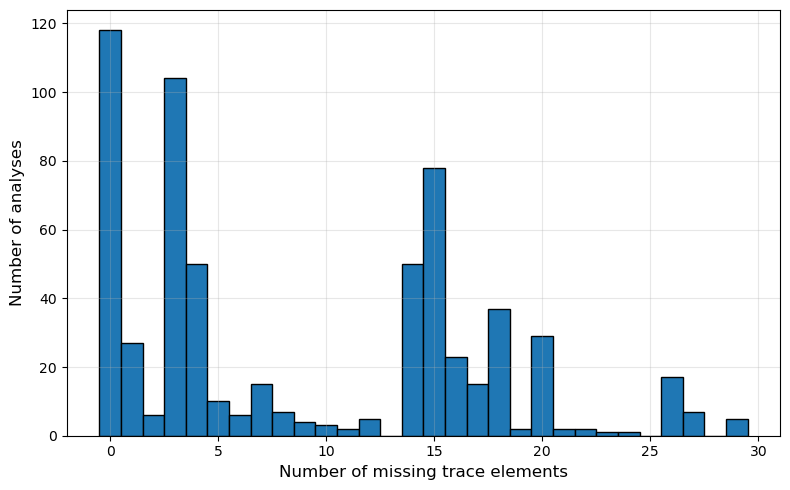

In [6]:
# =============================================================================
# Histogram of missing trace elements per analysis
# =============================================================================

# Number of missing trace elements in each analysis
missing_per_row = df[TRACE_ELEMENTS].isna().sum(axis=1)

fig, ax = plt.subplots(figsize=(8,5))

ax.hist(
    missing_per_row,
    bins=np.arange(-0.5, len(TRACE_ELEMENTS)+1.5, 1),
    edgecolor="black"
)

ax.set_xlabel("Number of missing trace elements", fontsize=12)
ax.set_ylabel("Number of analyses", fontsize=12)

ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

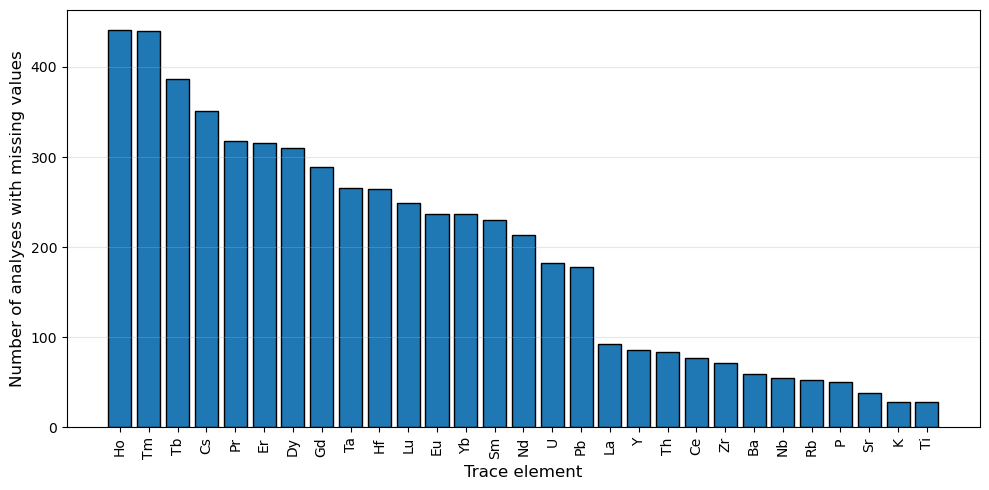

In [7]:
# =============================================================================
# Histogram of missing analyses per trace element
# =============================================================================

missing_per_element = df[TRACE_ELEMENTS].isna().sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10,5))

ax.bar(
    missing_per_element.index,
    missing_per_element.values,
    edgecolor="black"
)

ax.set_xlabel("Trace element", fontsize=12)
ax.set_ylabel("Number of analyses with missing values", fontsize=12)

ax.tick_params(axis="x", rotation=90)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# =============================================================================
# Export missingness summary tables
# =============================================================================

# -------------------------------------------------------------------------
# Row-wise missingness (per analysis)
# -------------------------------------------------------------------------

row_missing_summary = df[["Series", "Location"]].copy()

row_missing_summary["Measured_TE"] = df[TRACE_ELEMENTS].notna().sum(axis=1)
row_missing_summary["Missing_TE"] = df[TRACE_ELEMENTS].isna().sum(axis=1)
row_missing_summary["Completeness (%)"] = (
    100 * row_missing_summary["Measured_TE"] / len(TRACE_ELEMENTS)
)

# -------------------------------------------------------------------------
# Column-wise missingness (per trace element)
# -------------------------------------------------------------------------

column_missing_summary = pd.DataFrame({
    "Element": TRACE_ELEMENTS,
    "NaN Count": df[TRACE_ELEMENTS].isna().sum().values,
    "Missing (%)": (df[TRACE_ELEMENTS].isna().mean() * 100).values
}).sort_values("Missing (%)", ascending=False)

# -------------------------------------------------------------------------
# Save
# -------------------------------------------------------------------------

row_out = EXPORT_DIR / "01_row_missingness_summary.csv"
col_out = EXPORT_DIR / "02_trace_element_missingness_summary.csv"

row_missing_summary.to_csv(row_out, index=False)
column_missing_summary.to_csv(col_out, index=False)

print(f"Saved: {row_out}")
print(f"Saved: {col_out}")

Saved: C:\Users\d67199rs\OneDrive - The University of Manchester\Desktop\Lamproite\exports\01_row_missingness_summary.csv
Saved: C:\Users\d67199rs\OneDrive - The University of Manchester\Desktop\Lamproite\exports\02_trace_element_missingness_summary.csv


In [9]:
# =============================================================================
# Trace element completeness by location
# =============================================================================

row_missing_summary = df[["Series", "Location"]].copy()
row_missing_summary["Measured_TE"] = df[TRACE_ELEMENTS].notna().sum(axis=1)
row_missing_summary["Missing_TE"] = df[TRACE_ELEMENTS].isna().sum(axis=1)
row_missing_summary["Completeness (%)"] = 100 * row_missing_summary["Measured_TE"] / len(TRACE_ELEMENTS)

location_completeness = (
    row_missing_summary
    .groupby(["Series", "Location"])
    .agg(
        Analyses=("Location", "size"),
        Median_Measured_TE=("Measured_TE", "median"),
        Min_Measured_TE=("Measured_TE", "min"),
        Max_Measured_TE=("Measured_TE", "max"),
        Median_Missing_TE=("Missing_TE", "median"),
        Median_Completeness_pct=("Completeness (%)", "median")
    )
    .reset_index()
    .sort_values(["Series", "Median_Completeness_pct"], ascending=[True, True])
)

display(location_completeness)

outpath = EXPORT_DIR / "03_location_trace_element_completeness.csv"
location_completeness.to_csv(outpath, index=False)
print(f"Saved: {outpath}")

,Series,Location,Analyses,Median_Measured_TE,Min_Measured_TE,Max_Measured_TE,Median_Missing_TE,Median_Completeness_pct
8,Anorogenic,Utah (USA),2,3.0,3,3,26.0,10.344828
9,Anorogenic,Zambia,6,9.0,9,9,20.0,31.034483
1,Anorogenic,Australia,101,14.0,11,23,15.0,48.275862
6,Anorogenic,USA (Kansas),22,14.0,14,17,15.0,48.275862
4,Anorogenic,Norway,14,20.0,13,28,9.0,68.965517
5,Anorogenic,Russia,9,24.0,23,29,5.0,82.758621
0,Anorogenic,Antarctica,22,26.0,0,29,3.0,89.655172
2,Anorogenic,China (Yangtze Block),13,29.0,29,29,0.0,100.000000
3,Anorogenic,India,21,29.0,9,29,0.0,100.000000
7,Anorogenic,"USA (Leucite Hills, Wyoming)",6,29.0,25,29,0.0,100.000000


Saved: C:\Users\d67199rs\OneDrive - The University of Manchester\Desktop\Lamproite\exports\03_location_trace_element_completeness.csv


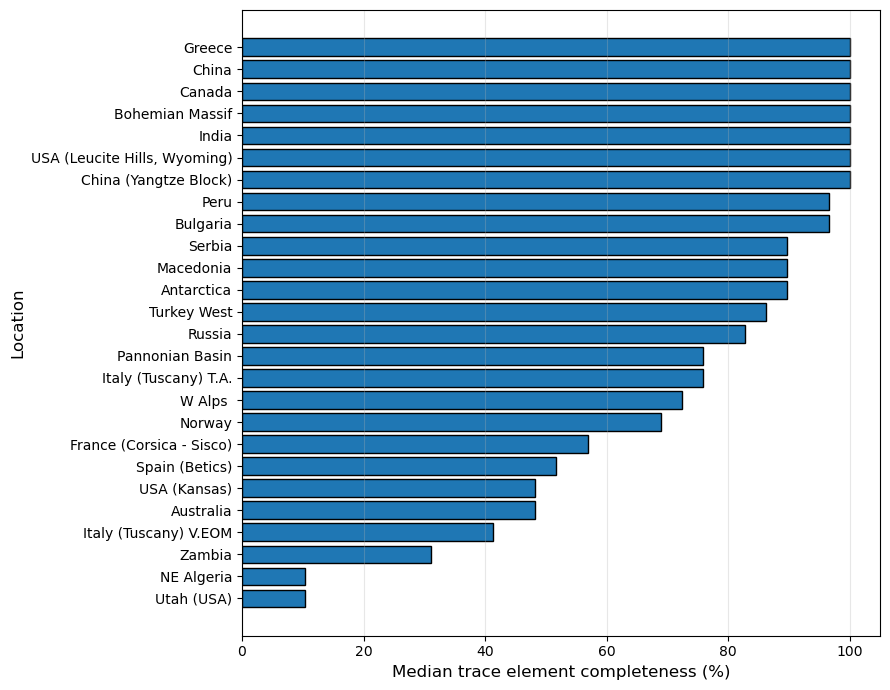

In [10]:
# =============================================================================
# Plot median trace element completeness by location
# =============================================================================

plot_df = location_completeness.sort_values("Median_Completeness_pct")

fig, ax = plt.subplots(figsize=(9, 7))

ax.barh(
    plot_df["Location"],
    plot_df["Median_Completeness_pct"],
    edgecolor="black"
)

ax.set_xlabel("Median trace element completeness (%)", fontsize=12)
ax.set_ylabel("Location", fontsize=12)
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Trace Element Retention Threshold Assessment

Evaluate how the number of retained trace elements affects dataset size, location coverage and retained multivariate information. For each threshold, the least-missing trace elements are retained, analyses with complete data for that retained element set are kept and the resulting number of samples, locations and sample × element cells is calculated.

A `RetentionScore` is also calculated to identify thresholds where the current gain in samples and locations is high, the next gain from removing another element is low and the retained data volume remains large.

In [11]:
# =============================================================================
# Assess retained element-count thresholds
# =============================================================================

element_missing_order = (
    df[TRACE_ELEMENTS]
    .isna()
    .sum()
    .sort_values(ascending=True)
)

element_threshold_results = []

max_elements = len(TRACE_ELEMENTS)

for n_elements in range(max_elements, 0, -1):

    retained_elements = element_missing_order.index[:n_elements].tolist()

    temp_df = df.dropna(subset=retained_elements).copy()

    n_samples = len(temp_df)
    n_locations = temp_df["Location"].nunique()

    element_threshold_results.append({
        "Retained_elements": n_elements,
        "Samples": n_samples,
        "Locations": n_locations,
        "Samples_x_elements": n_samples * n_elements
    })

element_threshold_df = pd.DataFrame(element_threshold_results)

# -------------------------------------------------------------------------
# Marginal gains after removing one additional element
# -------------------------------------------------------------------------

element_threshold_df["Current_ΔSamples"] = (
    element_threshold_df["Samples"].diff()
)

# -------------------------------------------------------------------------
# Marginal gains available after removing one more element
# -------------------------------------------------------------------------

element_threshold_df["Next_ΔSamples"] = (
    element_threshold_df["Current_ΔSamples"].shift(-1)
)


# -------------------------------------------------------------------------
# Candidate retention score
# -------------------------------------------------------------------------

current_gain = (  element_threshold_df["Current_ΔSamples"].fillna(0) )

future_gain = ( element_threshold_df["Next_ΔSamples"].fillna(0) )

element_threshold_df["RetentionScore"] = ( current_gain * (element_threshold_df["Samples_x_elements"]/1000) / (1 + future_gain)).round().astype(int)

display(element_threshold_df)

outpath = EXPORT_DIR / "04_element_count_threshold_assessment.csv"
element_threshold_df.to_csv(outpath, index=False)

print(f"Saved: {outpath}")

,Retained_elements,Samples,Locations,Samples_x_elements,Current_ΔSamples,Next_ΔSamples,RetentionScore
0,29,118,14,3422,NaN,12.0,0
1,28,130,14,3640,12.0,0.0,44
2,27,130,14,3510,0.0,85.0,0
3,26,215,17,5590,85.0,31.0,15
4,25,246,18,6150,31.0,3.0,48
5,24,249,18,5976,3.0,2.0,6
6,23,251,18,5773,2.0,9.0,1
7,22,260,18,5720,9.0,16.0,3
8,21,276,19,5796,16.0,2.0,31
9,20,278,19,5560,2.0,2.0,4


Saved: C:\Users\d67199rs\OneDrive - The University of Manchester\Desktop\Lamproite\exports\04_element_count_threshold_assessment.csv


## 9. Selected Trace Element Dataset Inspection and Export

Inspect the retained dataset generated using the selected 12 trace element threshold. This step verifies the retained predictor suite, total number of analyses, class balance and location coverage before exporting the final modelling dataset for subsequent machine learning analysis.

In [12]:
# =============================================================================
# Create modelling dataset
# =============================================================================

SELECTED_THRESHOLD = 12

retained_elements = (
    element_missing_order.index[:SELECTED_THRESHOLD]
    .tolist()
)

df_selected = df.dropna(subset=retained_elements).copy()

print("=" * 70)
print(f"RETAINED THRESHOLD = {SELECTED_THRESHOLD} ELEMENTS")
print("=" * 70)

print(f"Retained analyses : {len(df_selected)}")
print(f"Retained locations: {df_selected['Location'].nunique()}")

print("\nRetained trace elements:")
print(retained_elements)

series_summary = (
    df_selected.groupby("Series")
    .agg(
        Analyses=("Series", "size"),
        Locations=("Location", "nunique")
    )
)

print("\nSeries summary")
display(series_summary)

location_summary = (
    df_selected.groupby(["Series", "Location"])
    .size()
    .reset_index(name="Analyses")
    .sort_values(["Series", "Analyses"], ascending=[True, False])
)

print("\nLocation summary")
display(location_summary)

model_columns = META + retained_elements
df_model = df_selected[model_columns].copy()

df_model[retained_elements] = (
    df_model[retained_elements]
    .round(2)
)

outpath = PROCESSED_DIR / "Modelling_Dataset.csv"
df_model.to_csv(outpath, index=False)

print(f"\nSaved: {outpath}")

RETAINED THRESHOLD = 12 ELEMENTS
Retained analyses : 445
Retained locations: 22

Retained trace elements:
['K', 'Ti', 'Sr', 'P', 'Rb', 'Nb', 'Ba', 'Zr', 'Ce', 'Th', 'Y', 'La']

Series summary


,Analyses,Locations
Series,,
Anorogenic,156,7
Orogenic,289,15



Location summary


,Series,Location,Analyses
1,Anorogenic,Australia,100
3,Anorogenic,India,17
2,Anorogenic,China (Yangtze Block),13
0,Anorogenic,Antarctica,11
5,Anorogenic,Russia,8
6,Anorogenic,"USA (Leucite Hills, Wyoming)",5
4,Anorogenic,Norway,2
19,Orogenic,Spain (Betics),74
15,Orogenic,Macedonia,64
20,Orogenic,Turkey West,53



Saved: C:\Users\d67199rs\OneDrive - The University of Manchester\Desktop\Lamproite\data\processed\Modelling_Dataset.csv
